# ***AIR POLLUTION TRENDS IN HYDERABAD FROM JANUARY -AUGUST-2023***

### **This study aims to analyze air pollution trends in Hyderabad from January to August 2023 by identifying the most affected locations, determining the months and times of day with the highest pollution levels, comparing pollution levels between weekdays and weekends, and recognizing the most commonly occurring air pollutants across all monitoring areas.**

**Importing all required libraries**

In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Concating all the data frames in to single data frame (df)**

In [234]:
df1=pd.read_csv("/content/Air_Quality_Index_Data_01_2023.csv")
df2=pd.read_csv("/content/Air_Quality_Index_Data_02_2023.csv")
df3=pd.read_csv("/content/Air_Quality_Index_Data_03_2023.csv")
df4=pd.read_csv("/content/Air_Quality_Index_Data_04_2023.csv")
df5=pd.read_csv("/content/Air_Quality_Index_Data_05_2023.csv")
df6=pd.read_csv("/content/Air_Quality_Index_Data_06_2023.csv")
df7=pd.read_csv("/content/Air_Quality_Index_Data_07_2023.csv")
df8=pd.read_csv("/content/Air_Quality_Index_Data_08_2023.csv")

In [235]:
df=pd.concat([df1,df2,df3,df4,df5,df6,df7,df8],ignore_index=True)

**Data Cleaning**

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 684678 entries, 0 to 684677
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   year       684678 non-null  int64  
 1   month      684677 non-null  object 
 2   date       684675 non-null  object 
 3   time       684674 non-null  object 
 4   location   684674 non-null  object 
 5   indicator  684648 non-null  object 
 6   unit       684647 non-null  object 
 7   value      674422 non-null  object 
 8   note       0 non-null       float64
dtypes: float64(1), int64(1), object(7)
memory usage: 47.0+ MB


**Fixing Data Types (columns data type conversion)**

1. Date column of dataframe is object type so convet it in to datetime
2. Extract the hour column from the time
3. Value column is object type so convert it to numeric

In [237]:
df["date"]=pd.to_datetime(df["date"],dayfirst=True,errors="coerce")  # pands reads the month first but my date format is DD-MM-YYYY, so i mentioned dayfirst=True

In [238]:
df["hour"]=pd.to_datetime(df["time"],format="%H:%M",errors="coerce").dt.hour # Extract the hour column from the time

In [239]:
df["value"]=pd.to_numeric(df["value"],errors="coerce") # avoiding errors use (errors="coerce")

**Idnetify the Duplicates and drop the duplicates**

In [240]:
df.duplicated().sum()

np.int64(4560)

In [241]:
df.drop_duplicates()

,year,month,date,time,location,indicator,unit,value,note,hour
0,2023,January,2023-01-01,00:00,Bollaram Industrial Area,CO,mg/m³,1.4656,NaN,0.0
1,2023,January,2023-01-01,00:00,Bollaram Industrial Area,Ozone,µg/m³,20.1096,NaN,0.0
2,2023,January,2023-01-01,00:00,Bollaram Industrial Area,NO,µg/m³,2.7306,NaN,0.0
3,2023,January,2023-01-01,00:00,Bollaram Industrial Area,NO2,µg/m³,11.0168,NaN,0.0
4,2023,January,2023-01-01,00:00,Bollaram Industrial Area,NOx,ppb,8.0700,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
684673,2023,August,2023-08-09,22:00,ECIL KAPRA,ETHBENZ,ug/m3,2.7500,NaN,22.0
684674,2023,August,2023-08-09,22:00,ECIL KAPRA,NO,ug/m3,2.5800,NaN,22.0
684675,2023,August,2023-08-09,22:00,ECIL KAPRA,SR,W/m2,0.0000,NaN,22.0
684676,2023,August,2023-08-09,22:00,ECIL KAPRA,RF,m m,0.0000,NaN,22.0


**Handling with null values/ missing values**

1. note column has all null values hence drop it
2. Indicator column is a categorical so fill with mode
3. unit and value columns has null values less than 2% so drop the rows having
   null values.

In [242]:
# Calculating percentage of null
df.isnull().sum()/len(df)*100

,0
year,0.000000
month,0.000146
date,0.000438
time,0.000584
location,0.000584
indicator,0.004382
unit,0.004528
value,1.519254
note,100.000000
hour,0.000584


In [243]:
# note column has all null values so drop the note column.
df=df.dropna(axis=1,how="all")

In [244]:
# Indicator columns  is categorical so fill null values with mode
df["indicator"]=df["indicator"].fillna(df["indicator"].mode()[0])

In [245]:
# columns unit, and value having null values less than 2% so drop the null value rows
df.dropna(subset=["unit","value"],inplace=True)

In [246]:
# Deleating Year column why because already have a Date column(unwanted column)
df.drop("year",axis=1,inplace=True)

In [265]:
df.isnull().sum()

,0
month,0
date,0
time,0
location,0
indicator,0
unit,0
value,0
hour,0
time of day,0
Day_Name,0


In [247]:
# After dealing with nulls and duplicates details of data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 674252 entries, 0 to 684676
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   month      674252 non-null  object        
 1   date       674252 non-null  datetime64[ns]
 2   time       674252 non-null  object        
 3   location   674252 non-null  object        
 4   indicator  674252 non-null  object        
 5   unit       674252 non-null  object        
 6   value      674252 non-null  float64       
 7   hour       674252 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 46.3+ MB


**Standardize Text Entries**

1. To avoid the Inconsistancy apply str functions like strip() and upper()to
   standardize the names and remove duplicate entries.

In [248]:
# Nacharam is reflected two times so apply str function to remove duplicate entries due to inconsistancy
df["location"]=df["location"].str.strip().str.upper()

In [249]:
# unit and Indicator columns has incosistant errors lets resolve it
df["indicator"] = df["indicator"].str.strip().str.upper()
df["unit"] = df["unit"].str.strip().str.replace("µ","u").str.replace("²","2").replace({"°":"DEGREE","degrec":"degree","degreec":"degree"},regex=True).str.replace("³","3").str.replace("m m","mm").str.upper()
df[["indicator","unit"]].value_counts()

,,count
indicator,unit,
SO2,UG/M3,36012
OZONE,UG/M3,35988
CO,MG/M3,35980
NO2,UG/M3,35960
NO,UG/M3,35959
BENZENE,UG/M3,35948
NOX,PPB,35941
TOLUENE,UG/M3,35934
XYLENE,UG/M3,35930


In [250]:
# Split the 24 hours from hour column into four categories (late night, morning, after noon,night)
def time_of_day(hour):
   if 0<=hour<=6:
    return("Late Night")
   elif 6<hour<=12:
     return("Morning")
   elif 12<hour<=18:
     return("After noon")
   else:
    return("Night")
df["time of day"]=df["hour"].apply(time_of_day)


In [251]:
# Extract the Day Name from the Date column
df["Day_Name"]=df["date"].dt.day_name()

**Calculating AQI**

1. Data Frame has overall 22 Indicators.
2. pollutants= ['CO', 'Ozone', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'PM2.5',
   'PM10', 'Benzene', 'Toluene', 'Xylene','MP-Xylene', 'ETHBENZ']

3. Environmental indicators/ metrological parameters=['Temp','AT', 'RH', 'WS',
   'WD', 'SR', 'BP','RF']

4. The Central Pollution Control Board (CPCB) in India uses 8 pollutants to
   calculate the Air Quality Index
5. This Data Frame has 7 Indicators (PM2.5,PM10,NO2,SO2,CO,OZONE,NH3) for AQI Calculation by using these seven
   Indicators AQI is Calculated and remaing all indicators are droped.

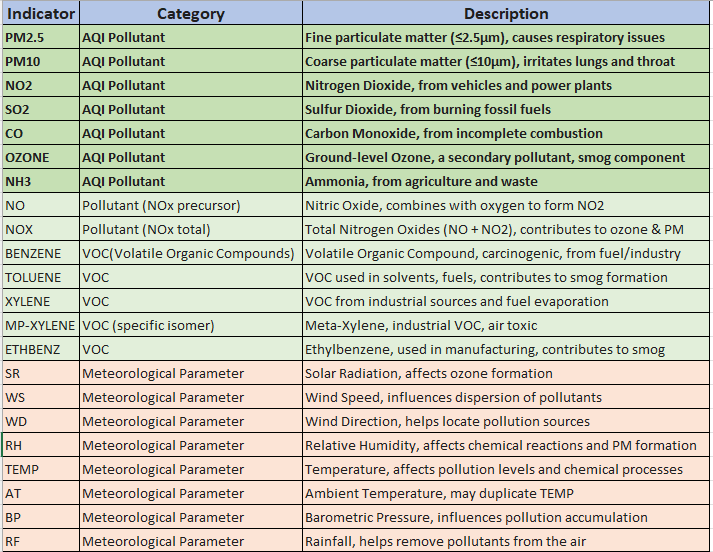

**Indian AQI BreakPoints**

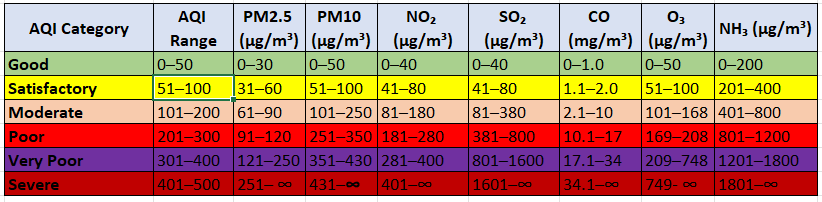

In [252]:
#AQI Breakpoints (c_low,c_high,"aqi_low,"aqi_max)
aqi_breakpoints= {
    'PM2.5': [(0, 30, 0, 50), (31, 60, 51, 100), (61, 90, 101, 200), (91, 120, 201, 300), (121, 250, 301, 400), (251, float('inf'), 401, 500)],
    'PM10': [(0, 50, 0, 50), (51, 100, 51, 100), (101, 250, 101, 200), (251, 350, 201, 300), (351, 430, 301, 400), (431, float('inf'), 401, 500)],
    'NO2': [(0, 40, 0, 50), (41, 80, 51, 100), (81, 180, 101, 200), (181, 280, 201, 300), (281, 400, 301, 400), (401, float('inf'), 401, 500)],
    'OZONE':[(0, 50, 0, 50), (51, 100, 51, 100), (101, 168, 101, 200), (169, 208, 201, 300), (209, 748, 301, 400), (749, float('inf'), 401, 500)],
    'CO': [(0, 1.0, 0, 50), (1.1, 2.0, 51, 100), (2.1, 10.0, 101, 200), (10.1, 17.0, 201, 300), (17.1, 34.0, 301, 400), (34.1, float('inf'), 401, 500)],
    'SO2': [(0, 40, 0, 50), (41, 80, 51, 100), (81, 380, 101, 200), (381, 800, 201, 300), (801, 1600, 301, 400), (1601, float('inf'), 401, 500)],
    'NH3': [(0, 200, 0, 50), (201, 400, 51, 100), (401, 800, 101, 200), (801, 1200, 201, 300), (1201, 1800, 301, 400), (1801, float('inf'), 401, 500)]}

In [253]:
def calculate_aqi(value, breakpoints):
    if pd.isna(value):
        return None
    for c_low, c_high, aqi_low, aqi_high in breakpoints:
        if c_low <= value <= c_high:
            return ((aqi_high - aqi_low) / (c_high - c_low)) * (value - c_low) + aqi_low
    return None

def get_pollutant_aqi(row):
    indicator = row['indicator']
    value = row['value']
    unit = row['unit']

    if indicator == 'PM2.5' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['PM2.5'])
    elif indicator == 'PM10' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['PM10'])
    elif indicator == 'NO2' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['NO2'])
    elif indicator == 'OZONE' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['OZONE'])
    elif indicator == 'CO' and unit == 'MG/M3':
        return calculate_aqi(value, aqi_breakpoints['CO'])
    elif indicator == 'SO2' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['SO2'])
    elif indicator == 'NH3' and unit == 'UG/M3':
        return calculate_aqi(value, aqi_breakpoints['NH3'])
    else:
        return None

In [254]:
# Apply the function to calculate individual pollutant AQI

df["AQI"] = df.apply(get_pollutant_aqi, axis=1)
df = df.dropna(subset=["AQI"])  # drop the nan values which are not involved in the AQI Calculation
df["AQI"]=df["AQI"].astype(int)  # AQI in converted in to int from float

<ipython-input-254-1f9d325f5615>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["AQI"]=df["AQI"].astype(int)  # AQI in converted in to int from float


***Handle Outliers ***

1. Identify the outliers Using IQR method
2. Identify the outliers Using Box plot.

In [255]:
# Using Inter Quartile Range(IQR)
Q1=df["value"].quantile(.25)
Q3=df["value"].quantile(.75)
IQR=Q3-Q1
# Calculating upper and lower bounds
lower_bound= Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

Outliers_IQR=df[(df["value"]<lower_bound)|(df["value"]>upper_bound)]
Outliers_IQR

,month,date,time,location,indicator,unit,value,hour,time of day,Day_Name,AQI
7,January,2023-01-01,00:00,BOLLARAM INDUSTRIAL AREA,PM2.5,UG/M3,85.0000,0.0,Late Night,Sunday,182
8,January,2023-01-01,00:00,BOLLARAM INDUSTRIAL AREA,PM10,UG/M3,165.0000,0.0,Late Night,Sunday,143
22,January,2023-01-01,00:00,CENTRAL UNIVERSITY,NO2,UG/M3,111.4276,0.0,Late Night,Sunday,131
27,January,2023-01-01,00:00,CENTRAL UNIVERSITY,PM10,UG/M3,178.0000,0.0,Late Night,Sunday,152
45,January,2023-01-01,00:00,ICRISAT PATANCHERU,PM2.5,UG/M3,85.0000,0.0,Late Night,Sunday,182
...,...,...,...,...,...,...,...,...,...,...,...
684549,August,2023-08-09,21:00,NACHARAM,PM10,UG/M3,123.7700,21.0,Night,Wednesday,116
684612,August,2023-08-09,21:00,ZOO PARK,PM10,UG/M3,88.0000,21.0,Night,Wednesday,88
684630,August,2023-08-09,22:00,BOLLARAM INDUSTRIAL AREA,PM2.5,UG/M3,85.0000,22.0,Night,Wednesday,182
684631,August,2023-08-09,22:00,BOLLARAM INDUSTRIAL AREA,PM10,UG/M3,237.0000,22.0,Night,Wednesday,191


<Axes: xlabel='indicator', ylabel='AQI'>

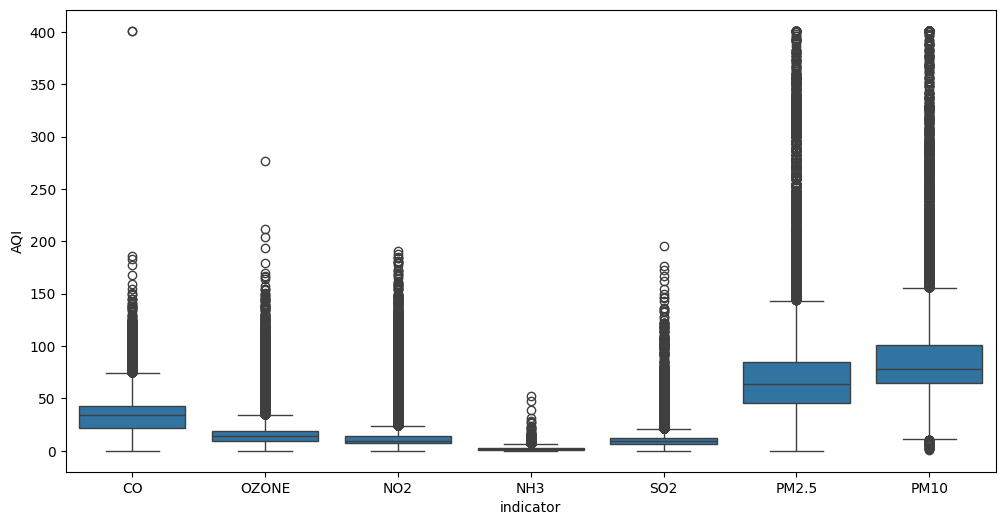

In [256]:
# Out liers calculation using Box Plot:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="indicator",y="AQI")

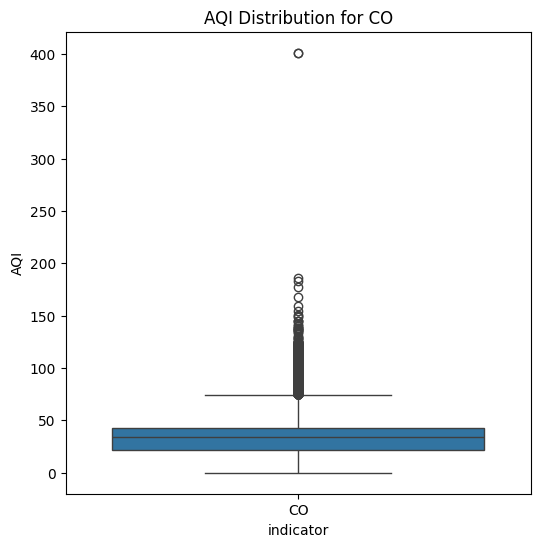

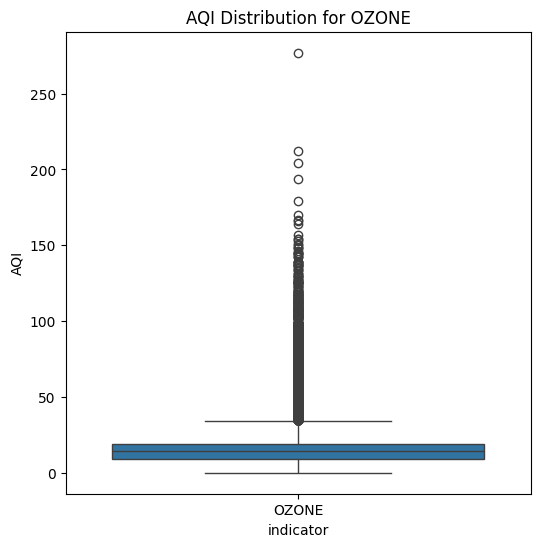

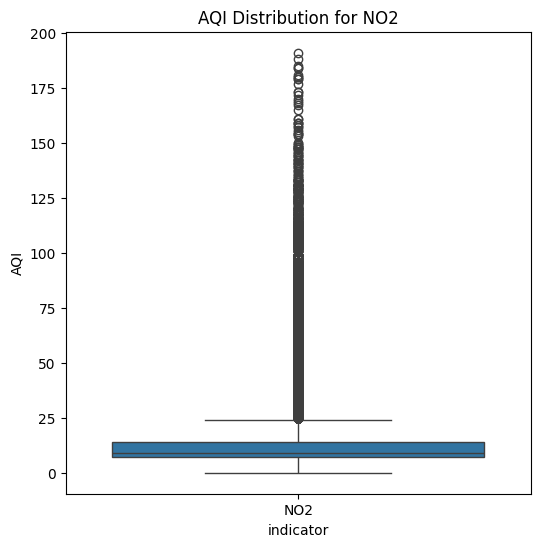

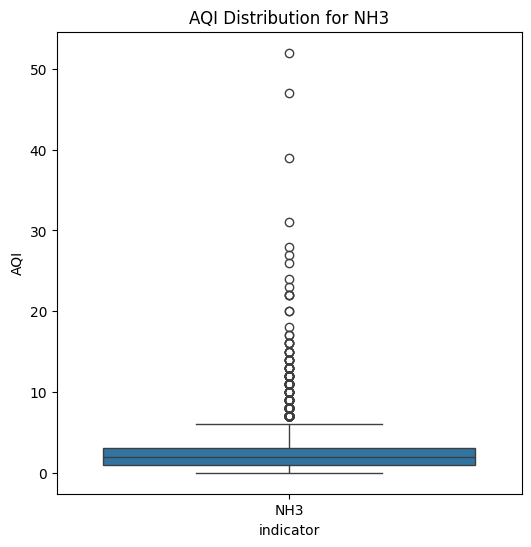

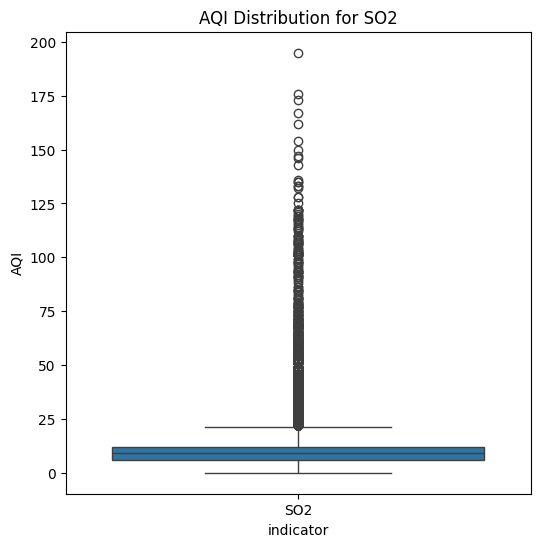

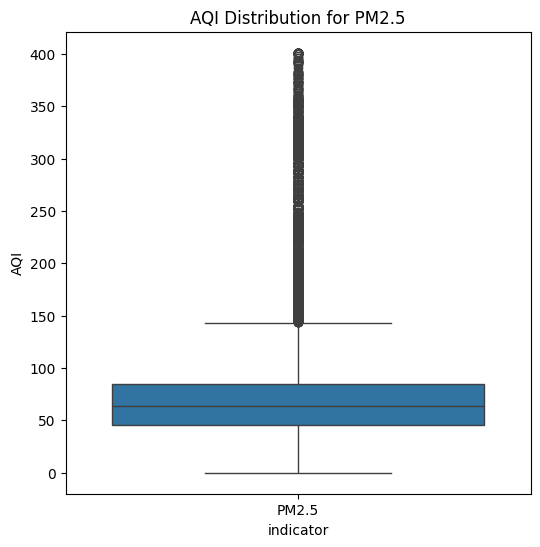

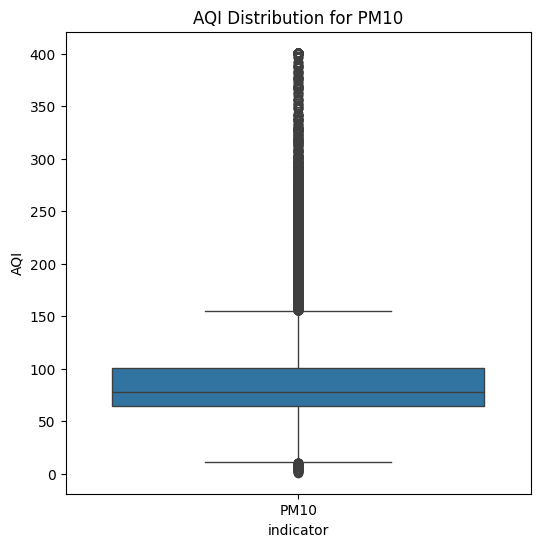

In [257]:
# Printing Individual Indicators Box Plot:
for indicator in df["indicator"].unique():
    plt.figure(figsize=(6, 6))
    sns.boxplot(data=df[df["indicator"] == indicator], x="indicator", y="AQI")
    plt.title(f"AQI Distribution for {indicator}")
    plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='indicator', ylabel='AQI'>

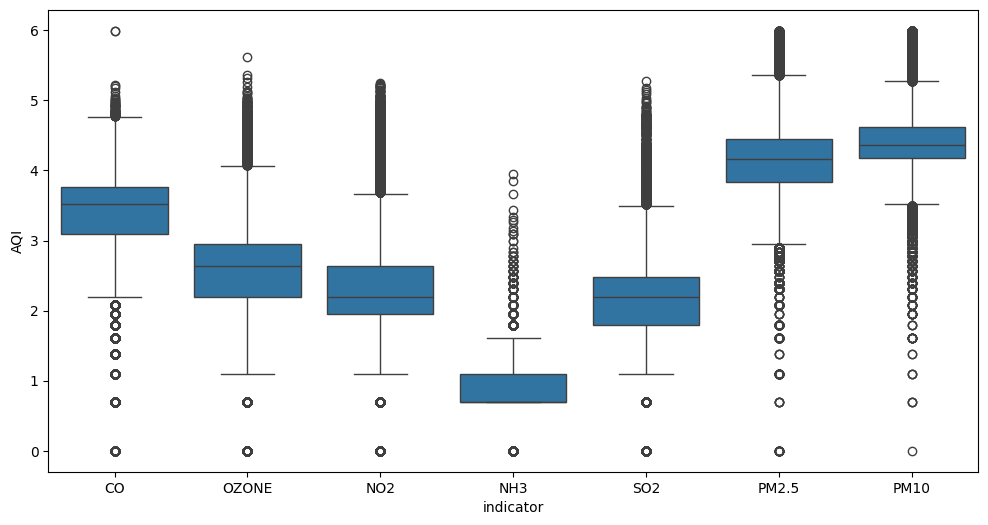

In [258]:
# Outlier Treatment using Log Function
log_AQI=np.log(df["AQI"])
plt.figure(figsize=(12,6))
sns.boxplot(df,x="indicator",y=np.log(df["AQI"]))

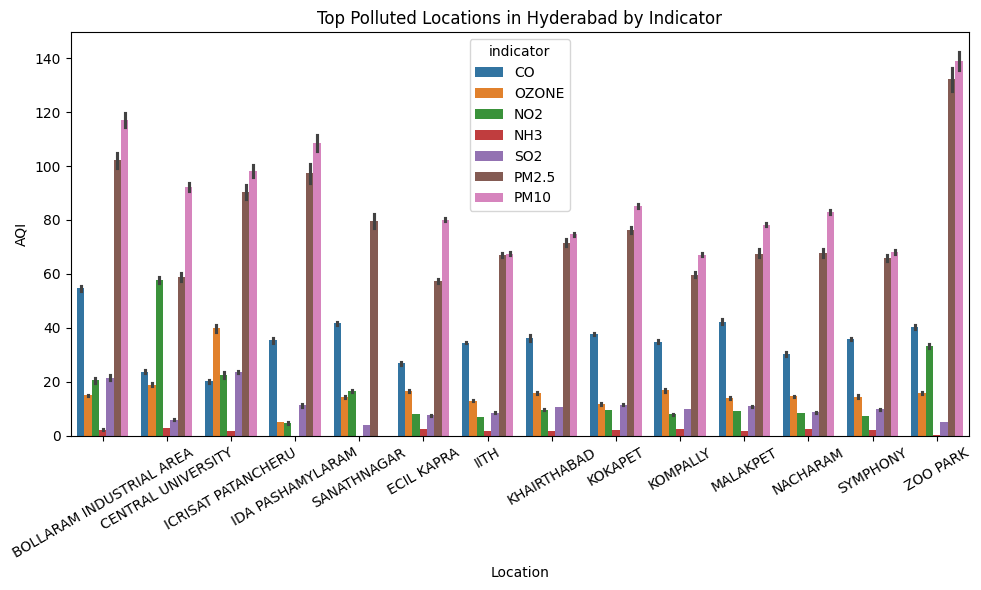

In [259]:
# Which location in Hyderabad recorded the highest levels of air pollution?
plt.figure(figsize=(10,6))
plt.xticks(rotation=30)
sns.barplot(df,x="location",y="AQI",hue="indicator")
plt.title("Top Polluted Locations in Hyderabad by Indicator")
plt.xlabel("Location")
plt.tight_layout()
plt.show()


**Most Affected Locations:** Bollaram Industrial Area, Zoo Park, IDA Pashamylaram, and Patancheru consistently record higher AQI levels.

These areas are likely affected by industrial emissions, vehicular pollution, and less green cover.

Kompally shows the lowest AQI, indicating better air quality, possibly due to lower traffic, industrial activity, or better ventilation.

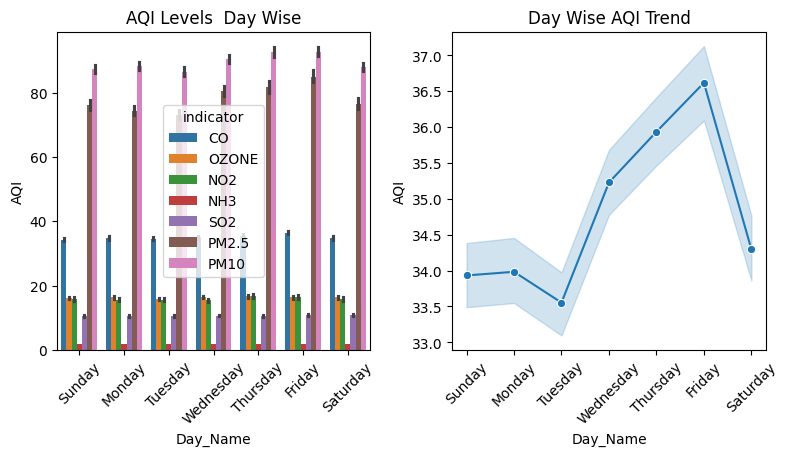

In [260]:
#During which Day was air pollution at its peak?
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.xticks(rotation=45)
sns.barplot(df,x="Day_Name",y="AQI",hue="indicator")
plt.title("AQI Levels  Day Wise")

plt.subplot(2,2,2)
sns.lineplot(df, x="Day_Name",y="AQI",marker="o")
plt.title("Day Wise AQI Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Weekend Air Quality Improvement: There's a noticeable dip in the overall AQI on Saturday and Sunday, indicating better air quality during the weekend.

Mid-Week Peak: The AQI generally increases through the weekdays, reaching its highest point around Thursday or Friday. This indicates the poorest air quality during this part of the week.

Weekly Cycle: The line plot clearly illustrates a weekly cycle in air quality, with higher pollution levels during the working days and lower levels on the weekend. This pattern likely reflects the changes in human activities throughout the week in Hyderabad.

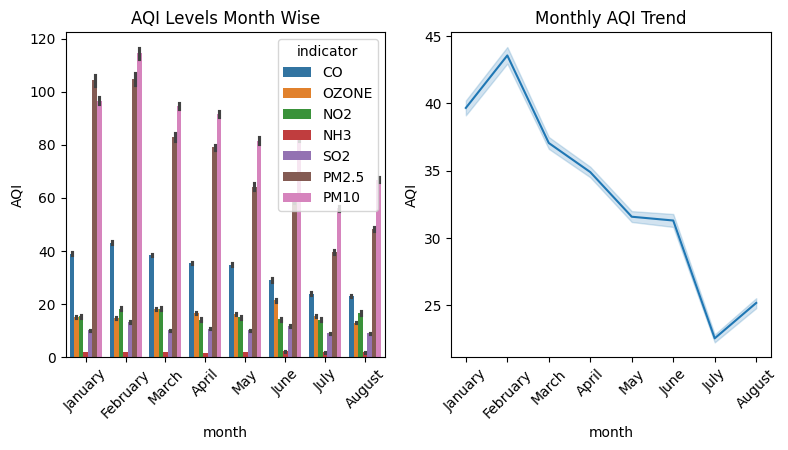

In [261]:
#During which Month air pollution at its peak?
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.xticks(rotation=45)
sns.barplot(df,x="month",y="AQI",hue="indicator")
plt.title("AQI Levels Month Wise")

plt.subplot(2,2,2)
sns.lineplot(df, x="month",y="AQI")
plt.title("Monthly AQI Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Monthly AQI Trends:**
AQI peaks in February, possibly due to:

1. Cooler weather trapping pollutants (temperature inversion).

2. Increased combustion activities (e.g., heating).

3. A steady decline is observed from March to July, with a slight rise again in
   August.

4. Monsoon influence (starting June) likely helps clear pollutants, improving
   air quality in July.

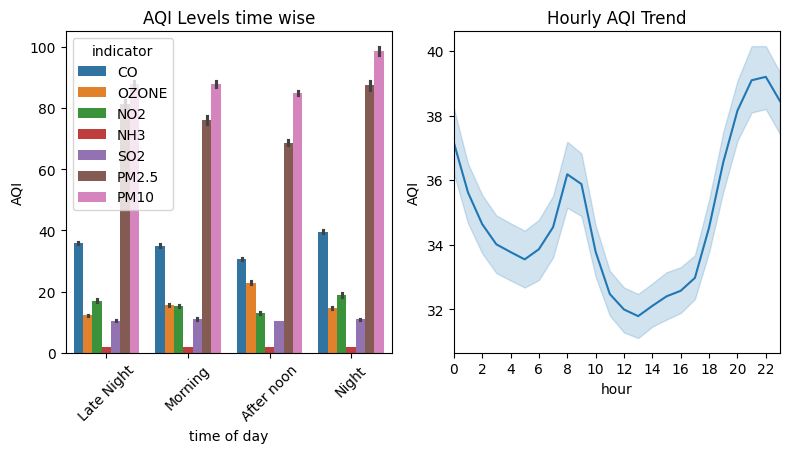

In [262]:
#During which time air pollution at its peak?
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.xticks(rotation=45)
sns.barplot(df,x="time of day",y="AQI",hue="indicator",palette="tab10")
plt.title("AQI Levels time wise")

plt.subplot(2,2,2)
sns.lineplot(df, x="hour",y="AQI")
plt.title("Hourly AQI Trend")
plt.xticks(ticks=(range(0,24,2)))
plt.tight_layout()
plt.xlim(0,23)
plt.show()

**Time-Wise and Hourly AQI Trends**:
1.  AQI is highest during Night and Late Night hours.

   Possible reasons: reduced wind speed, temperature drops, and pollution accumulation.

2. Hourly AQI follows a U-shape pattern:

 . Lowest around 10 AM – 3 PM, likely due to sunlight-driven dispersion.

 . Peaks again in the evening and early morning, consistent with traffic and  
  low dispersion.

<ipython-input-263-e87f3f2c804d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df,x="indicator",y="AQI",palette="muted")


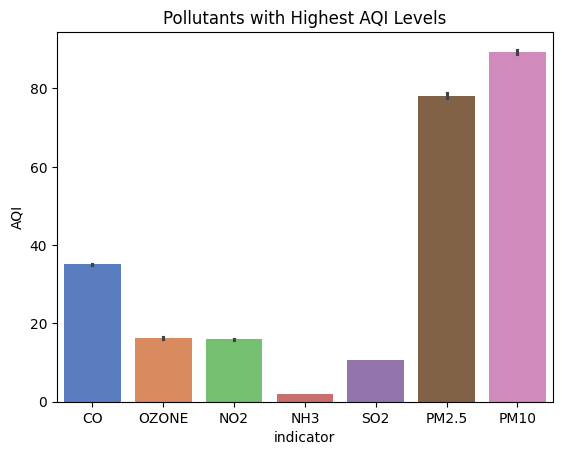

In [263]:
# which pollutant is most frequently recoreded high values
sns.barplot(df,x="indicator",y="AQI",palette="muted")
plt.title("Pollutants with Highest AQI Levels")
plt.show()

**Observations**
PM10 and PM2.5 are the dominant pollutants across all time slots and locations.

CO (Carbon Monoxide) also shows a significant presence, especially at night and in industrial zones.

Other pollutants like OZONE, NO2, NH3, SO2 are relatively lower in comparison.


# **Recommendations from AQI Analysis **

1. Control pollution in industrial areas like Bollaram, Zoo Park, and
   Pashamylaram by checking emissions and managing waste properly.

2. Reduce dust and smoke (PM10 & PM2.5) by watering roads, covering  
   construction sites, and using filters in factories.

3. Plant more trees in polluted zones to naturally clean the air.

4. Limit traffic during night and early morning, when pollution is highest, and
   promote carpooling or public transport.